In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add the project root to the system path

# Get the current working directory of the notebook
notebook_dir = os.getcwd()

# Navigate to the project root (adjust number of ".." as needed)
project_root = os.path.abspath(os.path.join(notebook_dir, "../"))
print(project_root)

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils.figures import *
import pandas as pd
import re

/Users/annaboser/Documents/GitHub/smallholder-irrigation-dataset


In [2]:
# Read in most recent data
most_recent_surveys = pd.read_csv("../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv")

# Progress statistics

In [3]:
label_count_table(most_recent_surveys)

,AB,DSB,JL,KL,MV,Total (unique),Total (not unique)
Surveys,1,11,10,12,11,41,45
Locations,21,243,234,265,256,933,1019
Images,51,588,582,681,623,2325,2525


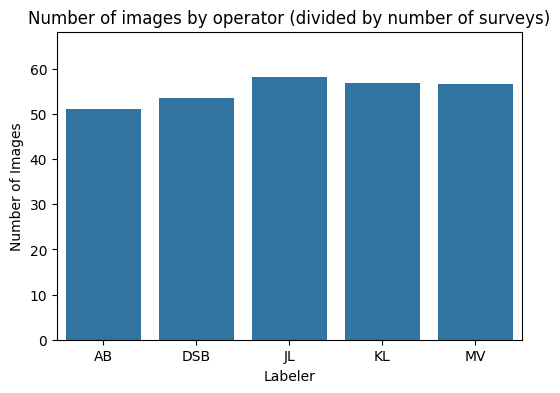

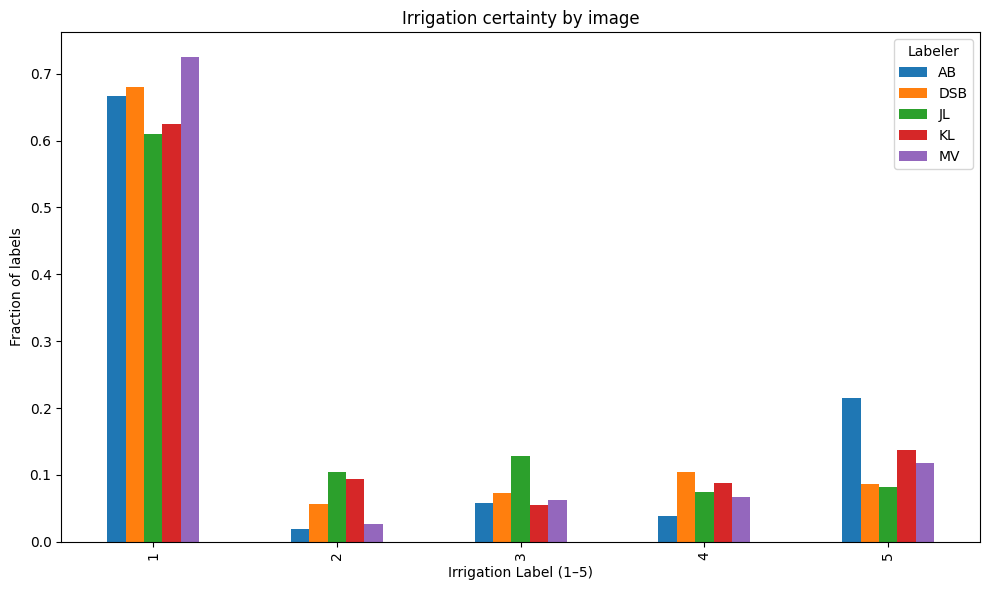

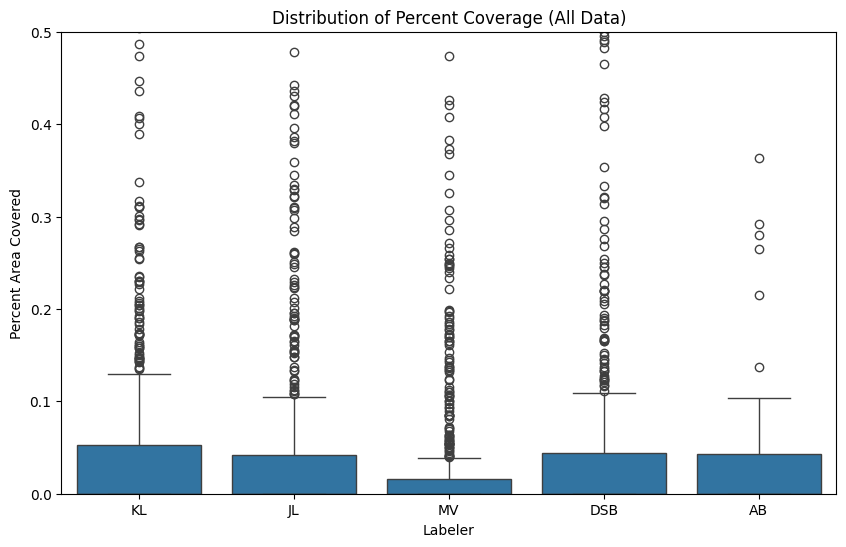

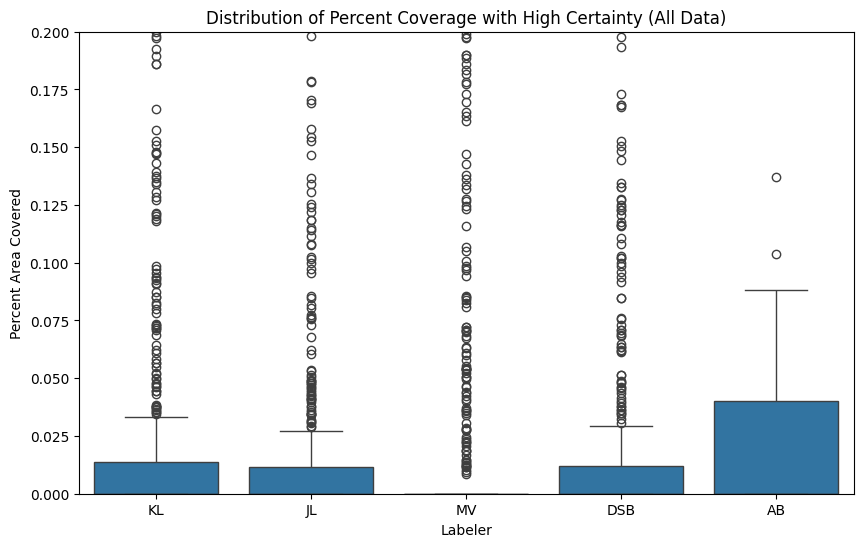

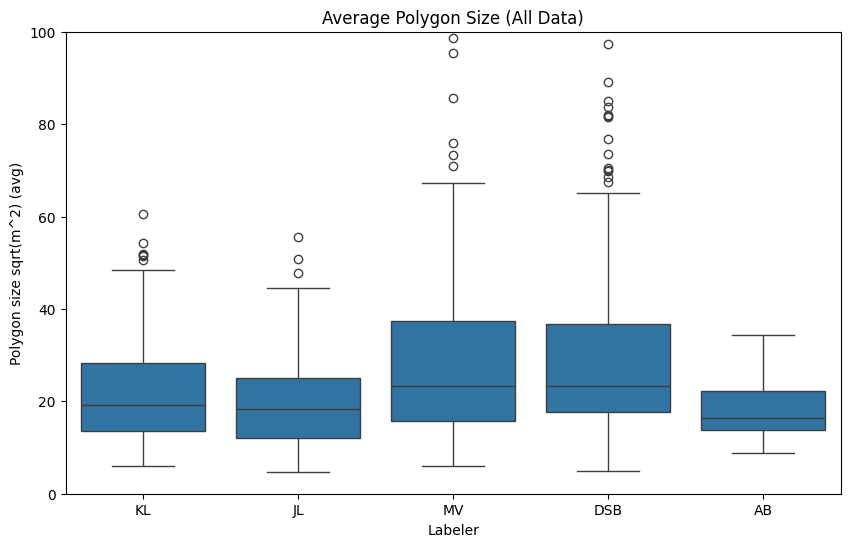

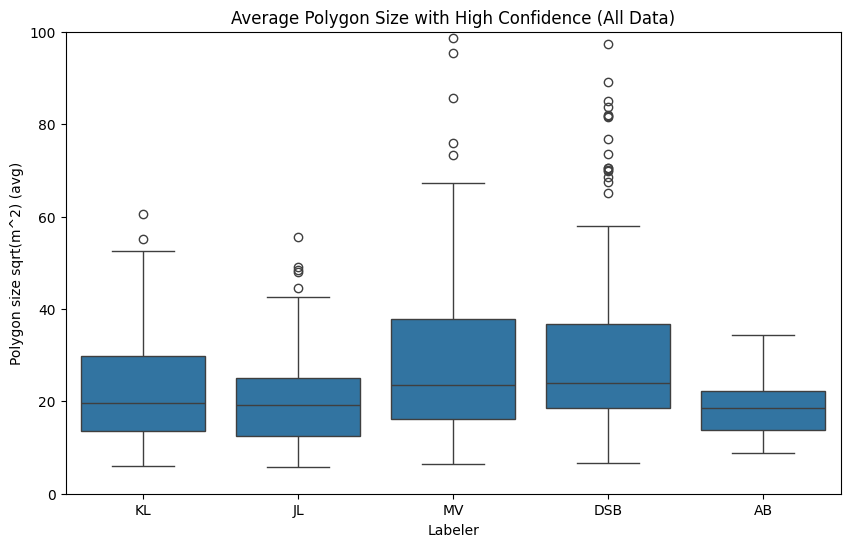

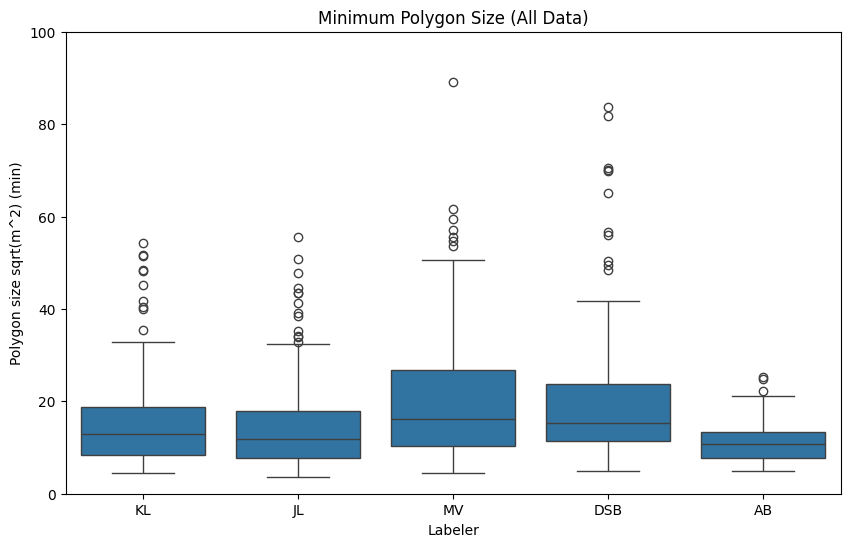

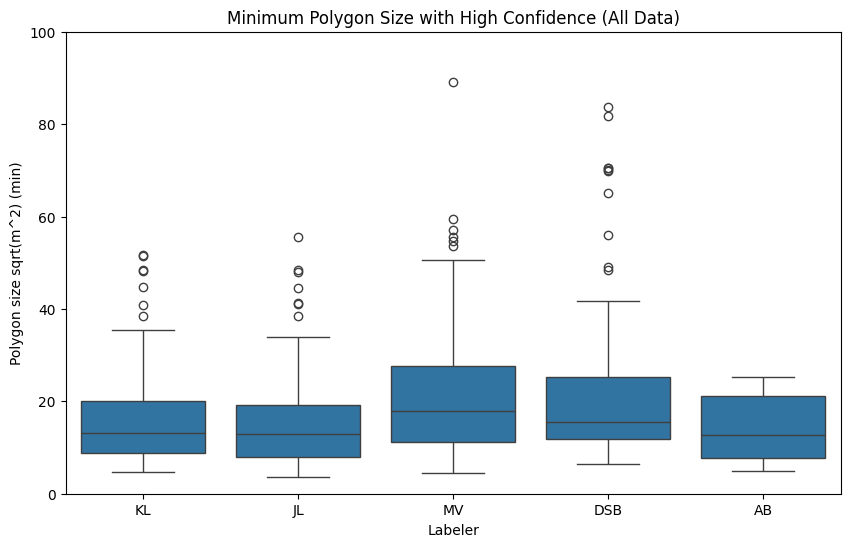

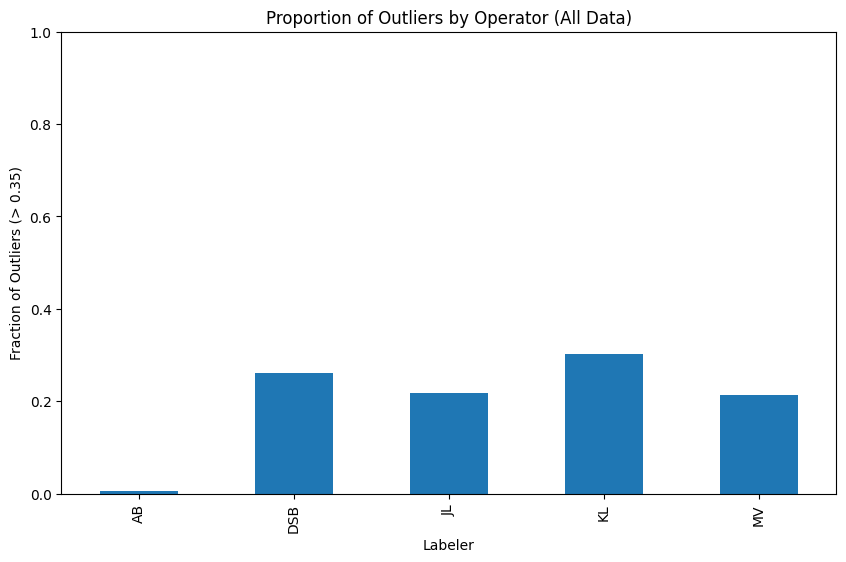

In [4]:
plot_num_images(most_recent_surveys, title="Number of images by operator (divided by number of surveys)", by_survey=True)
plot_irrigation_distribution(most_recent_surveys, title="Irrigation certainty by image")
plot_percent_coverage(most_recent_surveys, "Distribution of Percent Coverage (All Data)", certain_only=False, ymax=.5)
plot_percent_coverage(most_recent_surveys, "Distribution of Percent Coverage with High Certainty (All Data)", certain_only=True, ymax=.2)
plot_polygon_size(most_recent_surveys, "Average Polygon Size (All Data)", certain_only=False, ymax=100)
plot_polygon_size(most_recent_surveys, "Average Polygon Size with High Confidence (All Data)", certain_only=True, ymax=100)
plot_polygon_size(most_recent_surveys, "Minimum Polygon Size (All Data)", stat="min", certain_only=False, ymax=100)
plot_polygon_size(most_recent_surveys, "Minimum Polygon Size with High Confidence (All Data)", stat="min", certain_only=True, ymax=100)
plot_coverage_outliers(most_recent_surveys, title="Proportion of Outliers by Operator (All Data)", threshold=.35, certain_only=False)

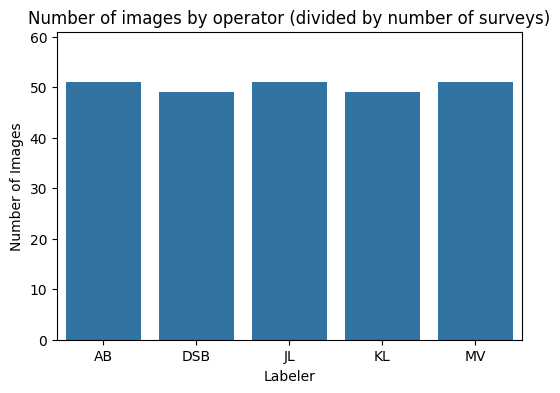

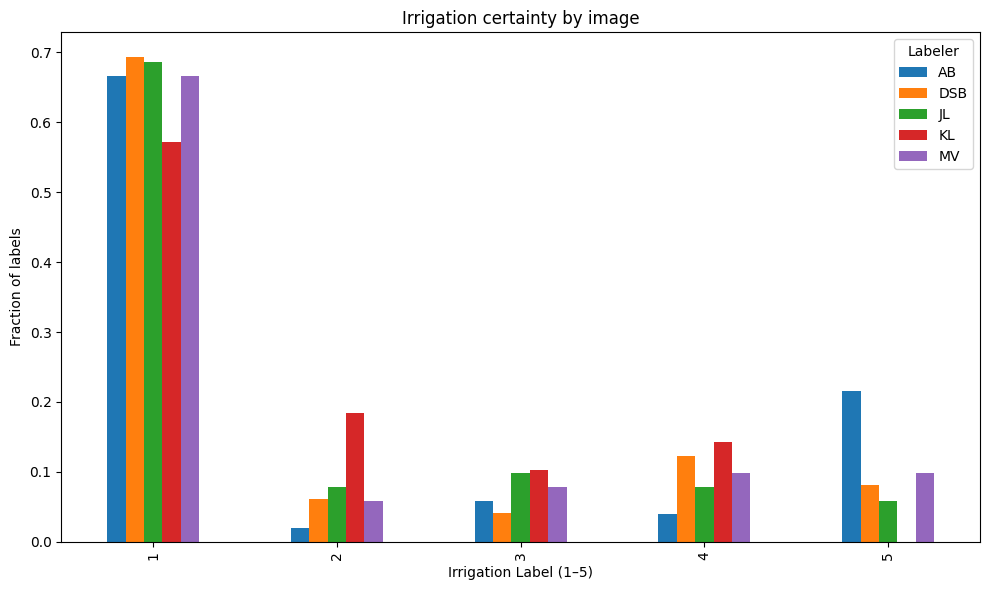

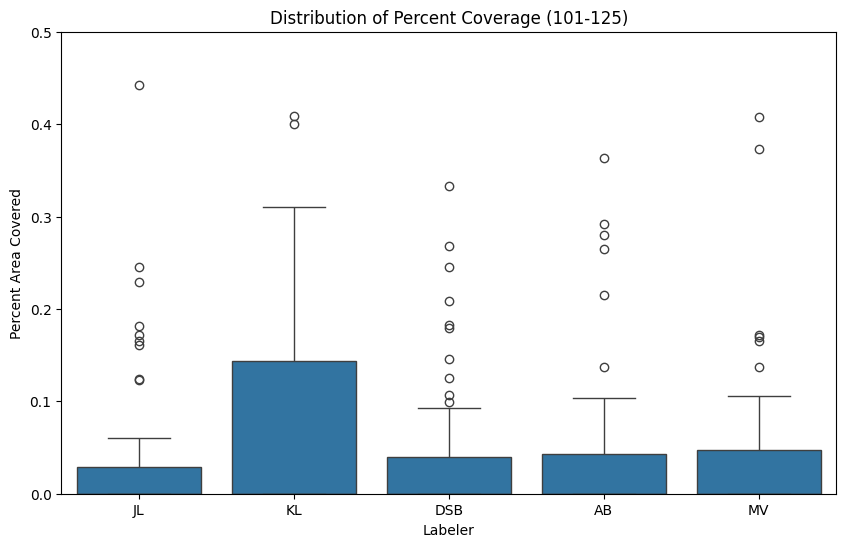

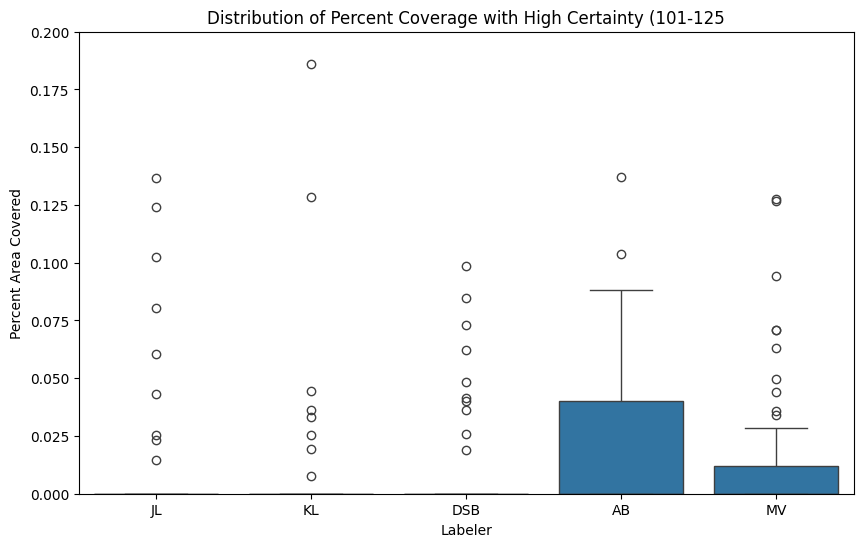

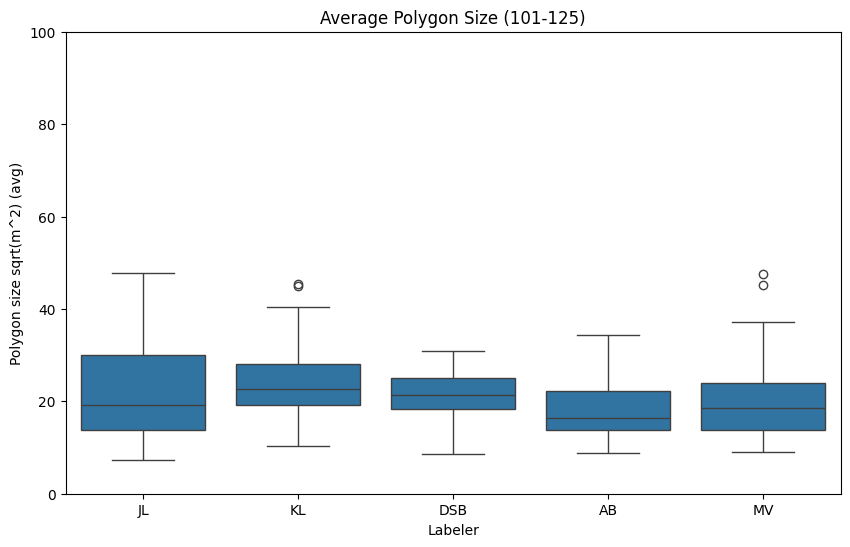

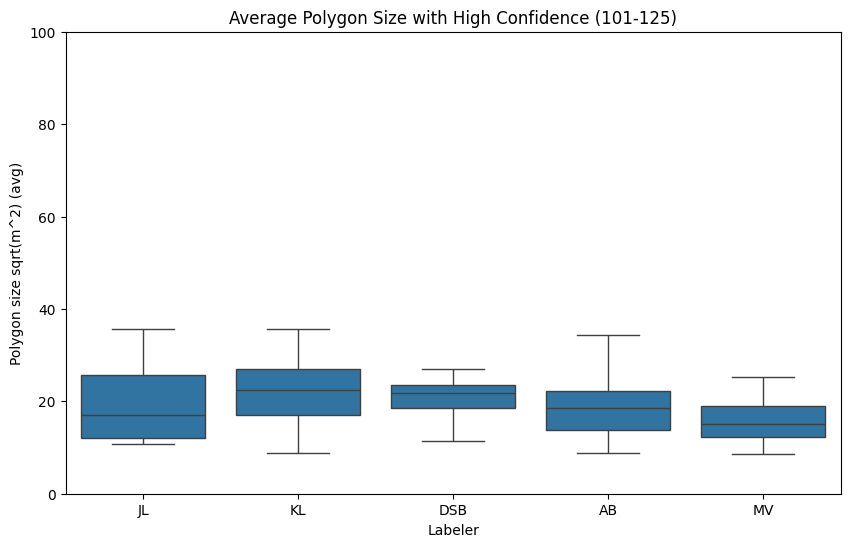

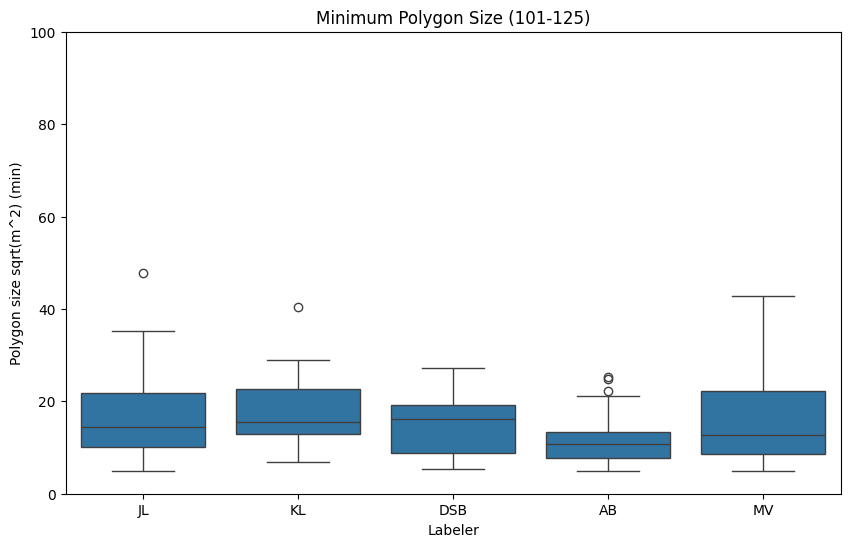

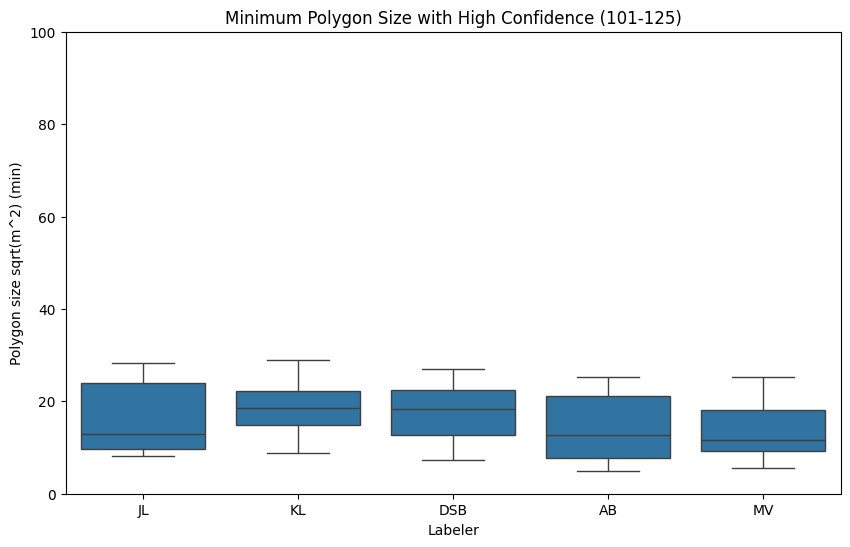

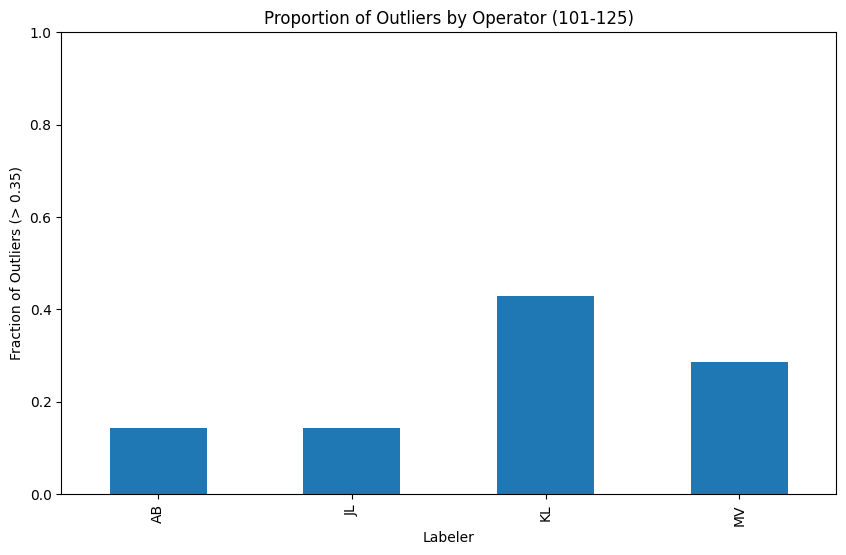

In [5]:
# Same thing but only for the 101 labels we all did

calibration_surveys = most_recent_surveys[most_recent_surveys['source_file'].str.contains('101-125')]

plot_num_images(calibration_surveys, title="Number of images by operator (divided by number of surveys)", by_survey=True)
plot_irrigation_distribution(calibration_surveys, title="Irrigation certainty by image")
plot_percent_coverage(calibration_surveys, "Distribution of Percent Coverage (101-125)", certain_only=False, ymax=.5)
plot_percent_coverage(calibration_surveys, "Distribution of Percent Coverage with High Certainty (101-125", certain_only=True, ymax=.2)
plot_polygon_size(calibration_surveys, "Average Polygon Size (101-125)", certain_only=False, ymax=100)
plot_polygon_size(calibration_surveys, "Average Polygon Size with High Confidence (101-125)", certain_only=True, ymax=100)
plot_polygon_size(calibration_surveys, "Minimum Polygon Size (101-125)", stat="min", certain_only=False, ymax=100)
plot_polygon_size(calibration_surveys, "Minimum Polygon Size with High Confidence (101-125)", stat="min", certain_only=True, ymax=100)
plot_coverage_outliers(calibration_surveys, title="Proportion of Outliers by Operator (101-125)", threshold=.35, certain_only=False)

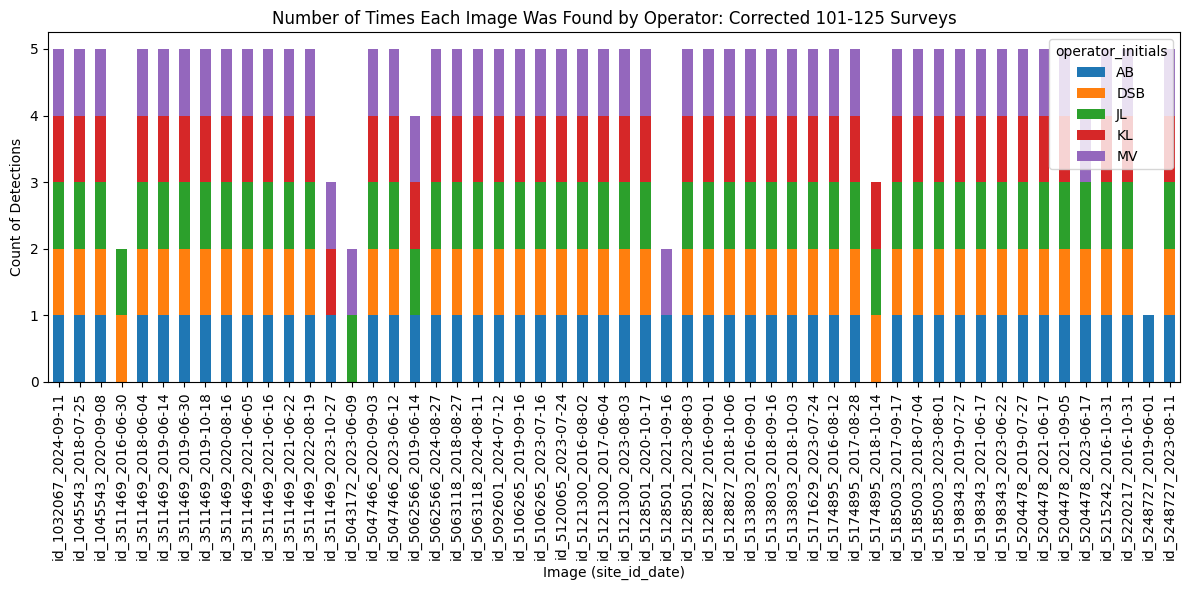

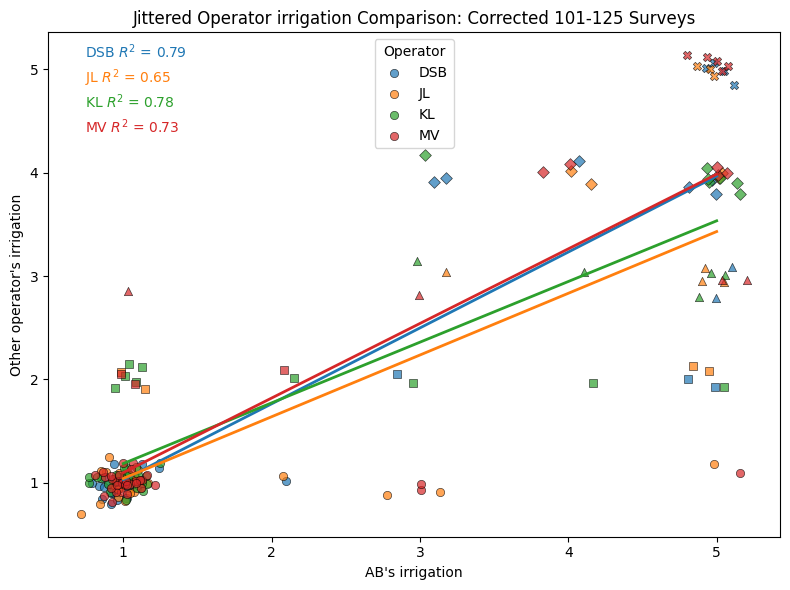

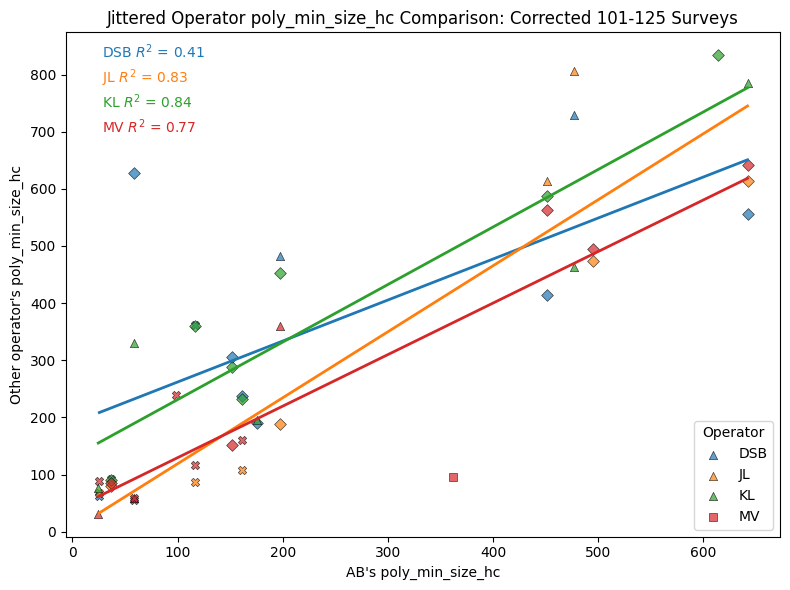

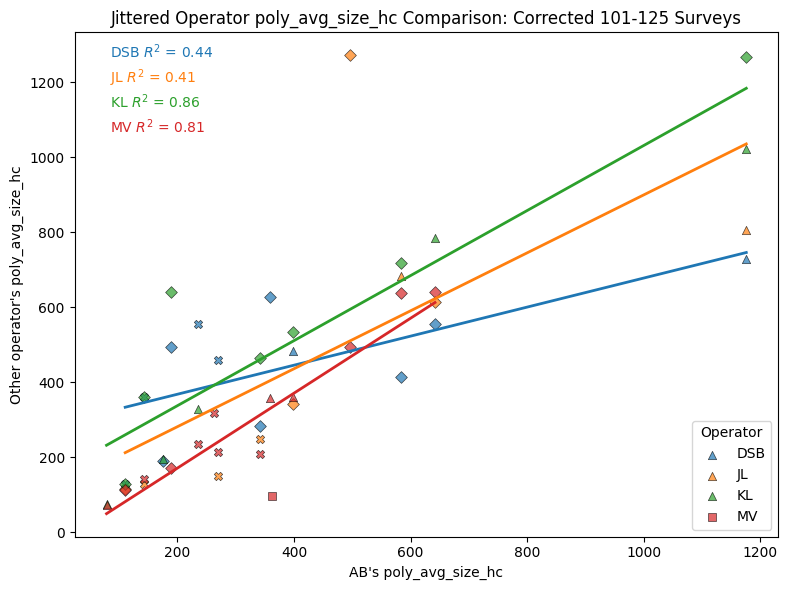

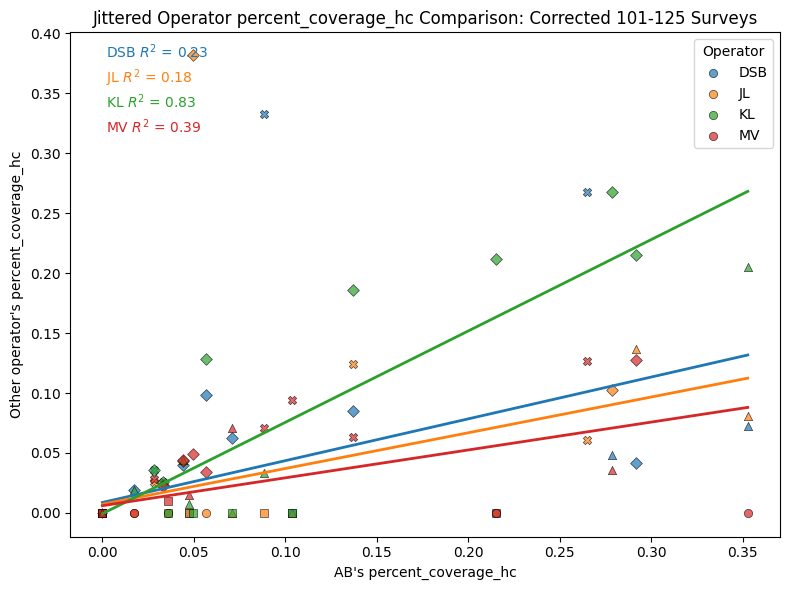

In [6]:
plot_image_counts(calibration_surveys, "Corrected 101-125 Surveys")
compare_to_AB(calibration_surveys, "Corrected 101-125 Surveys", "irrigation", jitter=True)
compare_to_AB(calibration_surveys, "Corrected 101-125 Surveys", "poly_min_size_hc")
compare_to_AB(calibration_surveys, "Corrected 101-125 Surveys", "poly_avg_size_hc")
compare_to_AB(calibration_surveys, "Corrected 101-125 Surveys", "percent_coverage_hc")

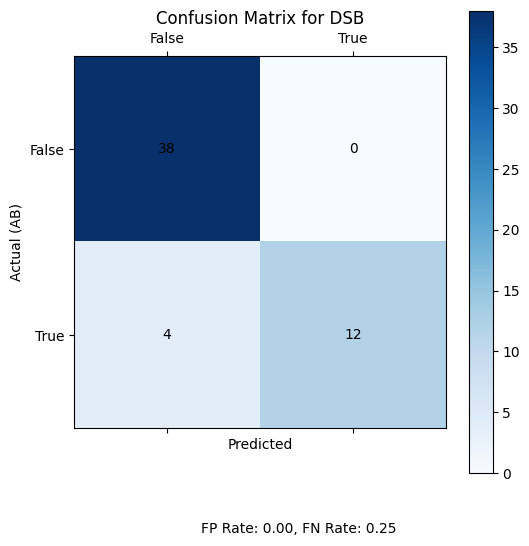

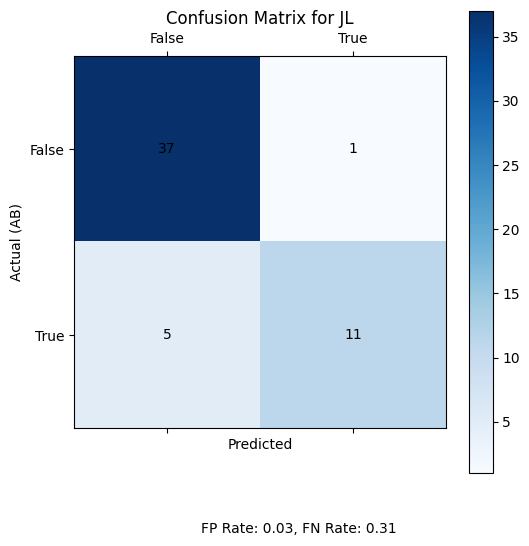

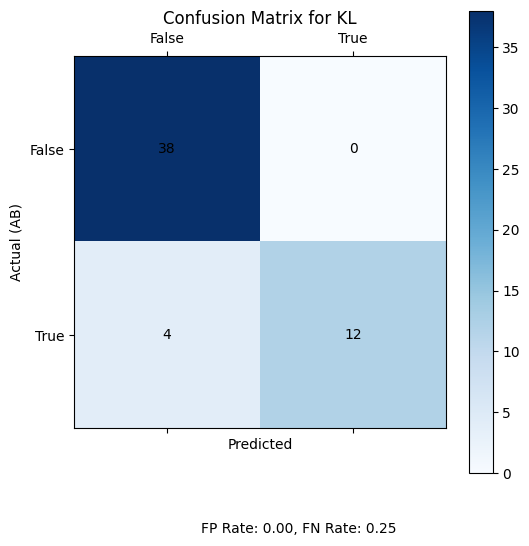

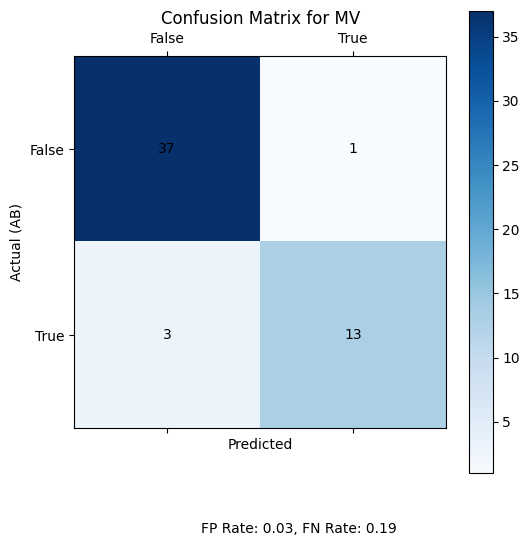

In [7]:

confusion_matrices = confusion_matrix(calibration_surveys, threshold=3)

